In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid") # configurando o estilo dos gráficos para melhor visualização

df = pd.read_csv('dados.csv', sep=';', decimal=',')
df['Nascimento'] = pd.to_datetime(df['Nascimento'], dayfirst=True, errors='coerce')
df['Dia'] = pd.to_datetime(df['Dia'], dayfirst=True, errors='coerce')
df = df.sort_values(by=['Atleta', 'Semana','Dia']) # Aqui estamos ordenando os dados para garantir que o preenchimento "para frente" (ffill) funcione corretamente, mantendo a sequência temporal de cada atleta.

# criando coluna idade em  anos inteiros apenas para ter uma variável numérica mais limpa
df['Idade'] = (df['Dia'] - df['Nascimento']).dt.days // 365


# Juntando as medições de PSE e TQR em colunas unificadas
def compute_pse_unificado(row):
    a = row.get('PSE QUA')
    b = row.get('PSE SAB')
    if pd.notna(a) and pd.notna(b):
        return (a + b) / 2
    elif pd.notna(a):
        return a
    elif pd.notna(b):
        return b
    else:
        return np.nan


def compute_tqr_unificado(row):
    vals = row[['TQR SEG', 'TQR QUA', 'TQR SEX']].dropna()
    if vals.empty:
        return np.nan
    return vals.mean()

df['PSE'] = df.apply(compute_pse_unificado, axis=1)
df['TQR'] = df.apply(compute_tqr_unificado, axis=1)

# categoriza a coluna cometição, ( vazio = 0, estadual = 1, nacional = 2, internacional = 3)
df['Competição'] = df['Competição'].map({
    np.nan: 0,
    'Estadual': 1,
    'Nacional': 2,
    'Internacional': 3
})


# Categorizando a coluna Período 
df['Período'] = df['Período'].map({
    np.nan: 0,
    'A1': 1,
    'A2': 2,
    'A3': 3,
    'B': 4,
    'B1': 5,
    'B2': 6,
    'AB': 7,
    'C': 8,
    'R': 9,
    'G': 10
})


# Categorizando o BRUMS (1=Bom, 2=Ok, 3=Ruim)
def classificar_brums(val, col):
    if pd.isna(val): return np.nan
    
    # Regras baseadas no Dicionário (Vermelho=3, Amarelo=2, Verde=1)
    if col == 'Tensão':
        return 3 if val >= 5.5 else (2 if val >= 4 else 1)
    elif col == 'Depressão':
        return 3 if val >= 2.5 else (2 if val >= 1.5 else 1)
    elif col == 'Raiva':
        return 3 if val >= 2.5 else (2 if val >= 1.5 else 1)
    elif col == 'Vigor': # Invertido: Baixo vigor é Ruim (3)
        return 3 if val <= 6 else (2 if val < 8 else 1)
    elif col == 'Fadiga':
        return 3 if val >= 4.5 else (2 if val >= 3 else 1)
    elif col == 'Confusão':
        return 3 if val >= 4 else (2 if val >= 2.5 else 1)
    return np.nan

brums_cols = ['Tensão', 'Depressão', 'Raiva', 'Vigor', 'Fadiga', 'Confusão']
brums_cat_cols = []

for col in brums_cols:
    new_col = f'{col}'
    df[new_col] = df[col].apply(lambda x: classificar_brums(x, col))
    brums_cat_cols.append(new_col)



# Tratando o Afastamento para criar um Indicador
# preencher NaNs com zero para facilitar os testes
df['Afastamento T'] = df['Afastamento T'].fillna(0)
df['Afastamento P'] = df['Afastamento P'].fillna(0)


# criando coluna feminino e masculino atraves da categoria de peso do judô
def infer_sex(cat):
    if cat in [48, 52, 57, 63, 70, 78]: return 0 # Feminino
    elif cat in [60, 66, 73, 81, 90, 100]: return 1 # Masculino
    else: return 'Unknown'

df['Sexo'] = df['Categoria'].apply(infer_sex)

# unificação categórica explicita (0=nada,1=apenas P,2=apenas T,3=conflito)
cond = [
    (df['Afastamento P'] == 0) & (df['Afastamento T'] == 0),
    (df['Afastamento P'] > 0) & (df['Afastamento T'] == 0),
    (df['Afastamento P'] == 0) & (df['Afastamento T'] > 0)
]
choices = [0, 1, 2]
df['Afastamento'] = np.select(cond, choices, default=3)

#dropando colunas inuteis:
df.drop(columns=['Nascimento', 'Dia','PSE QUA', 'PSE SAB', 'TQR SEG', 'TQR QUA', 'TQR SEX'], inplace=True)


In [7]:
# Criandoa coluna do "Próximo Estado" (t+1) para cada atleta
# Usamos o shift(-1) agrupado por atleta para não misturar dados de pessoas diferentes
df['Afastamento_Prox'] = df.groupby('Atleta')['Afastamento'].shift(-1)
df_transicao = df.dropna(subset=['Afastamento_Prox']).copy() # Removemos a última linha de cada atleta (onde o próximo estado seria NaN)
matriz_freq = pd.crosstab(df_transicao['Afastamento'], df_transicao['Afastamento_Prox']) # Criamos uma tabela cruzada (contingência) entre o estado atual e o próximo
matriz_transicao = matriz_freq.div(matriz_freq.sum(axis=1), axis=0)  # Normalizamos pelas linhas para obter probabilidades (soma da linha = 1)


#  Calculando o Tempo Esperado no Estado i
# O tempo esperado em um estado em uma cadeia de Markov discreta é 1 / (1 - P(i,i))
# onde P(i,i) é a probabilidade de permanecer no mesmo estado.
tempos_esperados = {}
for estado in matriz_transicao.index:
    if estado in matriz_transicao.columns:
        p_ii = matriz_transicao.loc[estado, estado]
        
        # Evitar divisão por zero se a probabilidade de sair for 100%
        if p_ii < 1.0:
            tempo_medio = 1 / (1 - p_ii)
        else:
            tempo_medio = float('inf') # Estado absorvente
            
        tempos_esperados[estado] = tempo_medio

for estado, tempo in tempos_esperados.items():
    print(f"Estado {estado}: {tempo:.2f} períodos")


Estado 0: 22.53 períodos
Estado 1: 3.10 períodos
Estado 2: 2.71 períodos


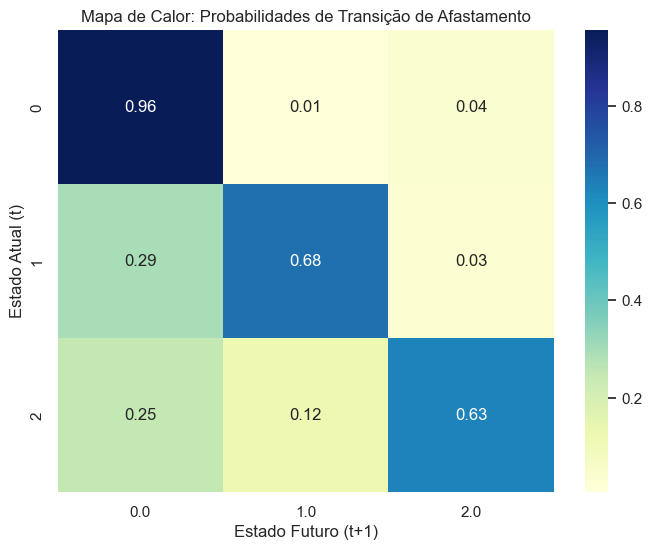

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_transicao, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Mapa de Calor: Probabilidades de Transição de Afastamento')
plt.xlabel('Estado Futuro (t+1)')
plt.ylabel('Estado Atual (t)')
plt.show()

In [2]:
df.to_excel('dados_processados_para_modelo.xlsx', index=False)

In [24]:
#vendo quanasn mulheres e homens tem em cada categoria e em geral
print(df['Sexo'].value_counts(dropna=False))
print("\n--- Distribuição de Sexo por Categoria ---")
print(df.groupby(['Categoria', 'Sexo']).size())

Sexo
1    946
0    624
Name: count, dtype: int64

--- Distribuição de Sexo por Categoria ---
Categoria  Sexo
48         0       111
52         0        74
57         0       111
60         1       188
63         0       114
66         1       145
70         0        71
73         1       152
78         0       143
81         1       181
90         1        74
100        1       206
dtype: int64


In [25]:
# printando quantas linhas vazias tem para cada coluna de 1555 linhas
missing_data = df.isnull().sum()
print(missing_data)

Atleta                   0
Categoria                0
Semana                   0
Período                 56
Competição               0
Pesagem               1119
Afastamento T            0
Afastamento P            0
Tensão                 752
Depressão              752
Raiva                  752
Vigor                  752
Fadiga                 752
Confusão               752
Notas                 1091
Teste Salto Squat     1484
Teste Salto CMJ       1484
Teste Agachamento     1458
Teste Supino          1368
Teste Remada          1366
Teste Salto Tatame    1460
Teste Barra           1404
UK Velocidade         1376
UK Resistência        1377
Idade                    0
PSE                    443
TQR                    389
Sexo                     0
dtype: int64


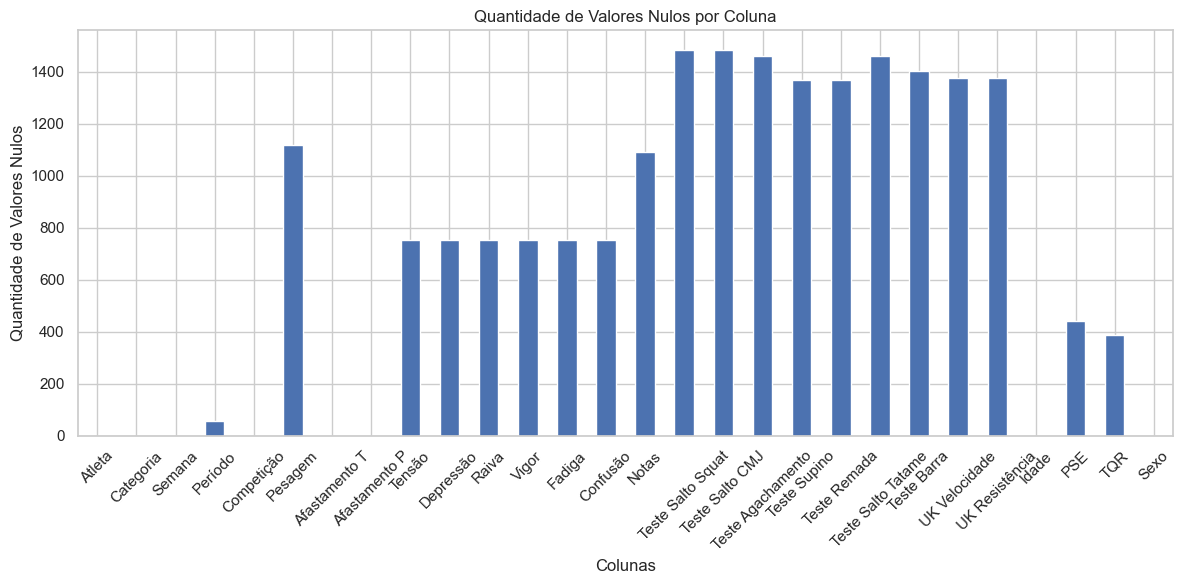

In [26]:
# Plotando quantas linhas vazias tem para cada coluna
plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum()
missing_data.plot(kind='bar')
plt.title('Quantidade de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de Valores Nulos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Adrian\AppData\Local\Temp\ipykernel_23368\638928801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[cat_col], ax=axes[i], palette='viridis', order=[1.0, 2.0, 3.0])
C:\Users\Adrian\AppData\Local\Temp\ipykernel_23368\638928801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[cat_col], ax=axes[i], palette='viridis', order=[1.0, 2.0, 3.0])
C:\Users\Adrian\AppData\Local\Temp\ipykernel_23368\638928801.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[cat_col], ax=axes[i], palette='viridis', order=[1.0, 2.0, 3

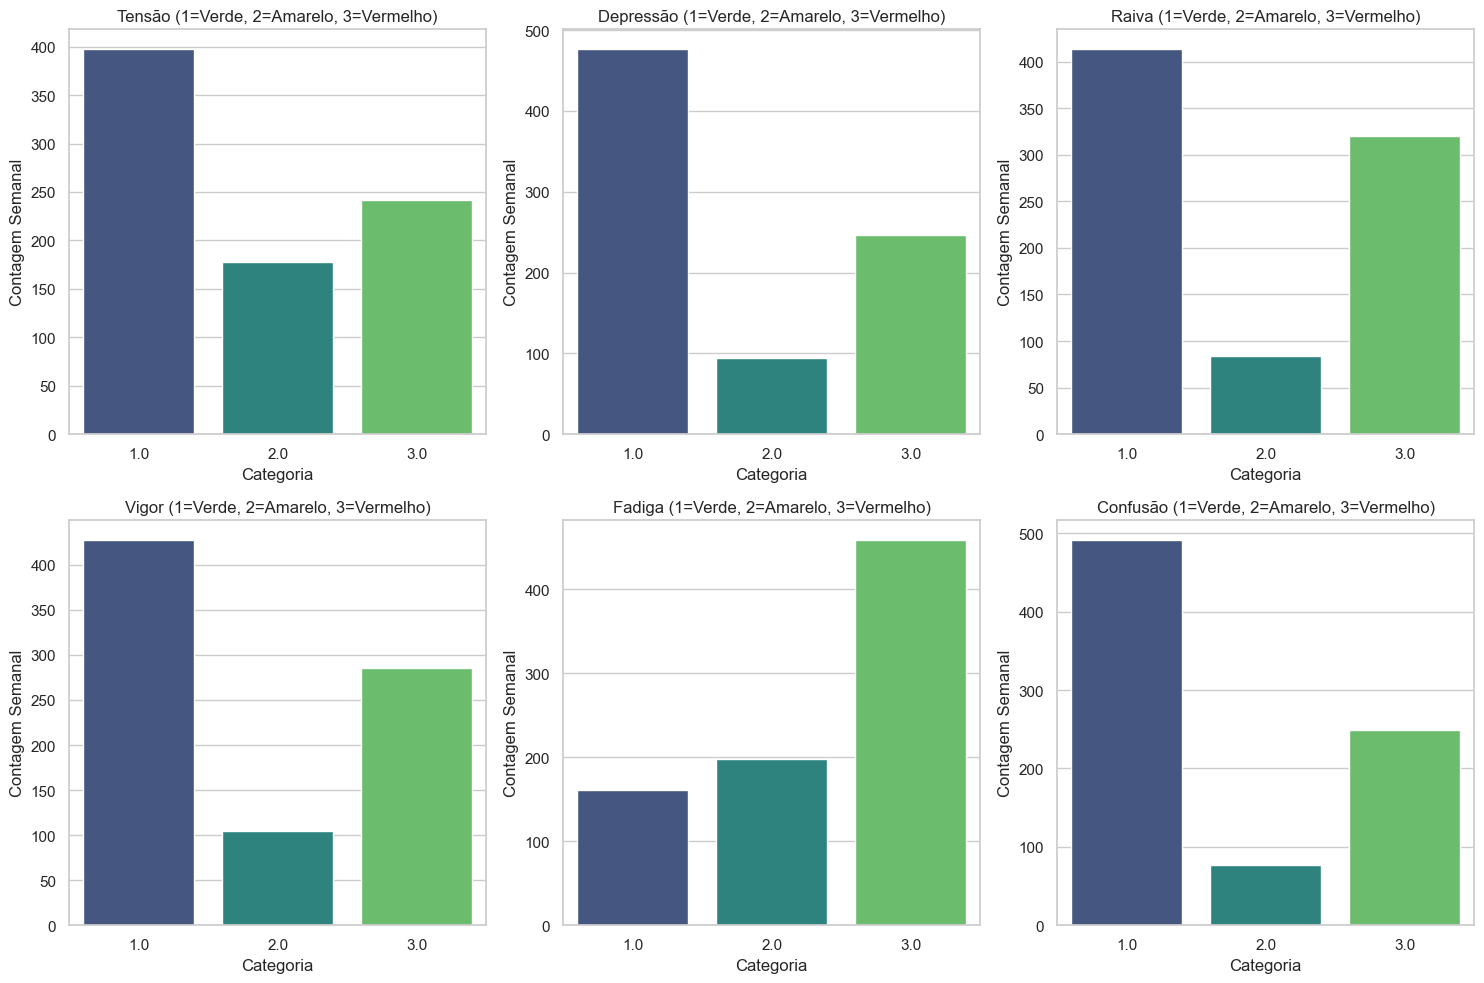

In [27]:
# Histogramas das Categorias do BRUMS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(brums_cols):
    cat_col = f'{col}'
    sns.countplot(x=df[cat_col], ax=axes[i], palette='viridis', order=[1.0, 2.0, 3.0])
    axes[i].set_title(f'{col} (1=Verde, 2=Amarelo, 3=Vermelho)')
    axes[i].set_ylabel('Contagem Semanal')
    axes[i].set_xlabel('Categoria')

plt.tight_layout()
plt.show()

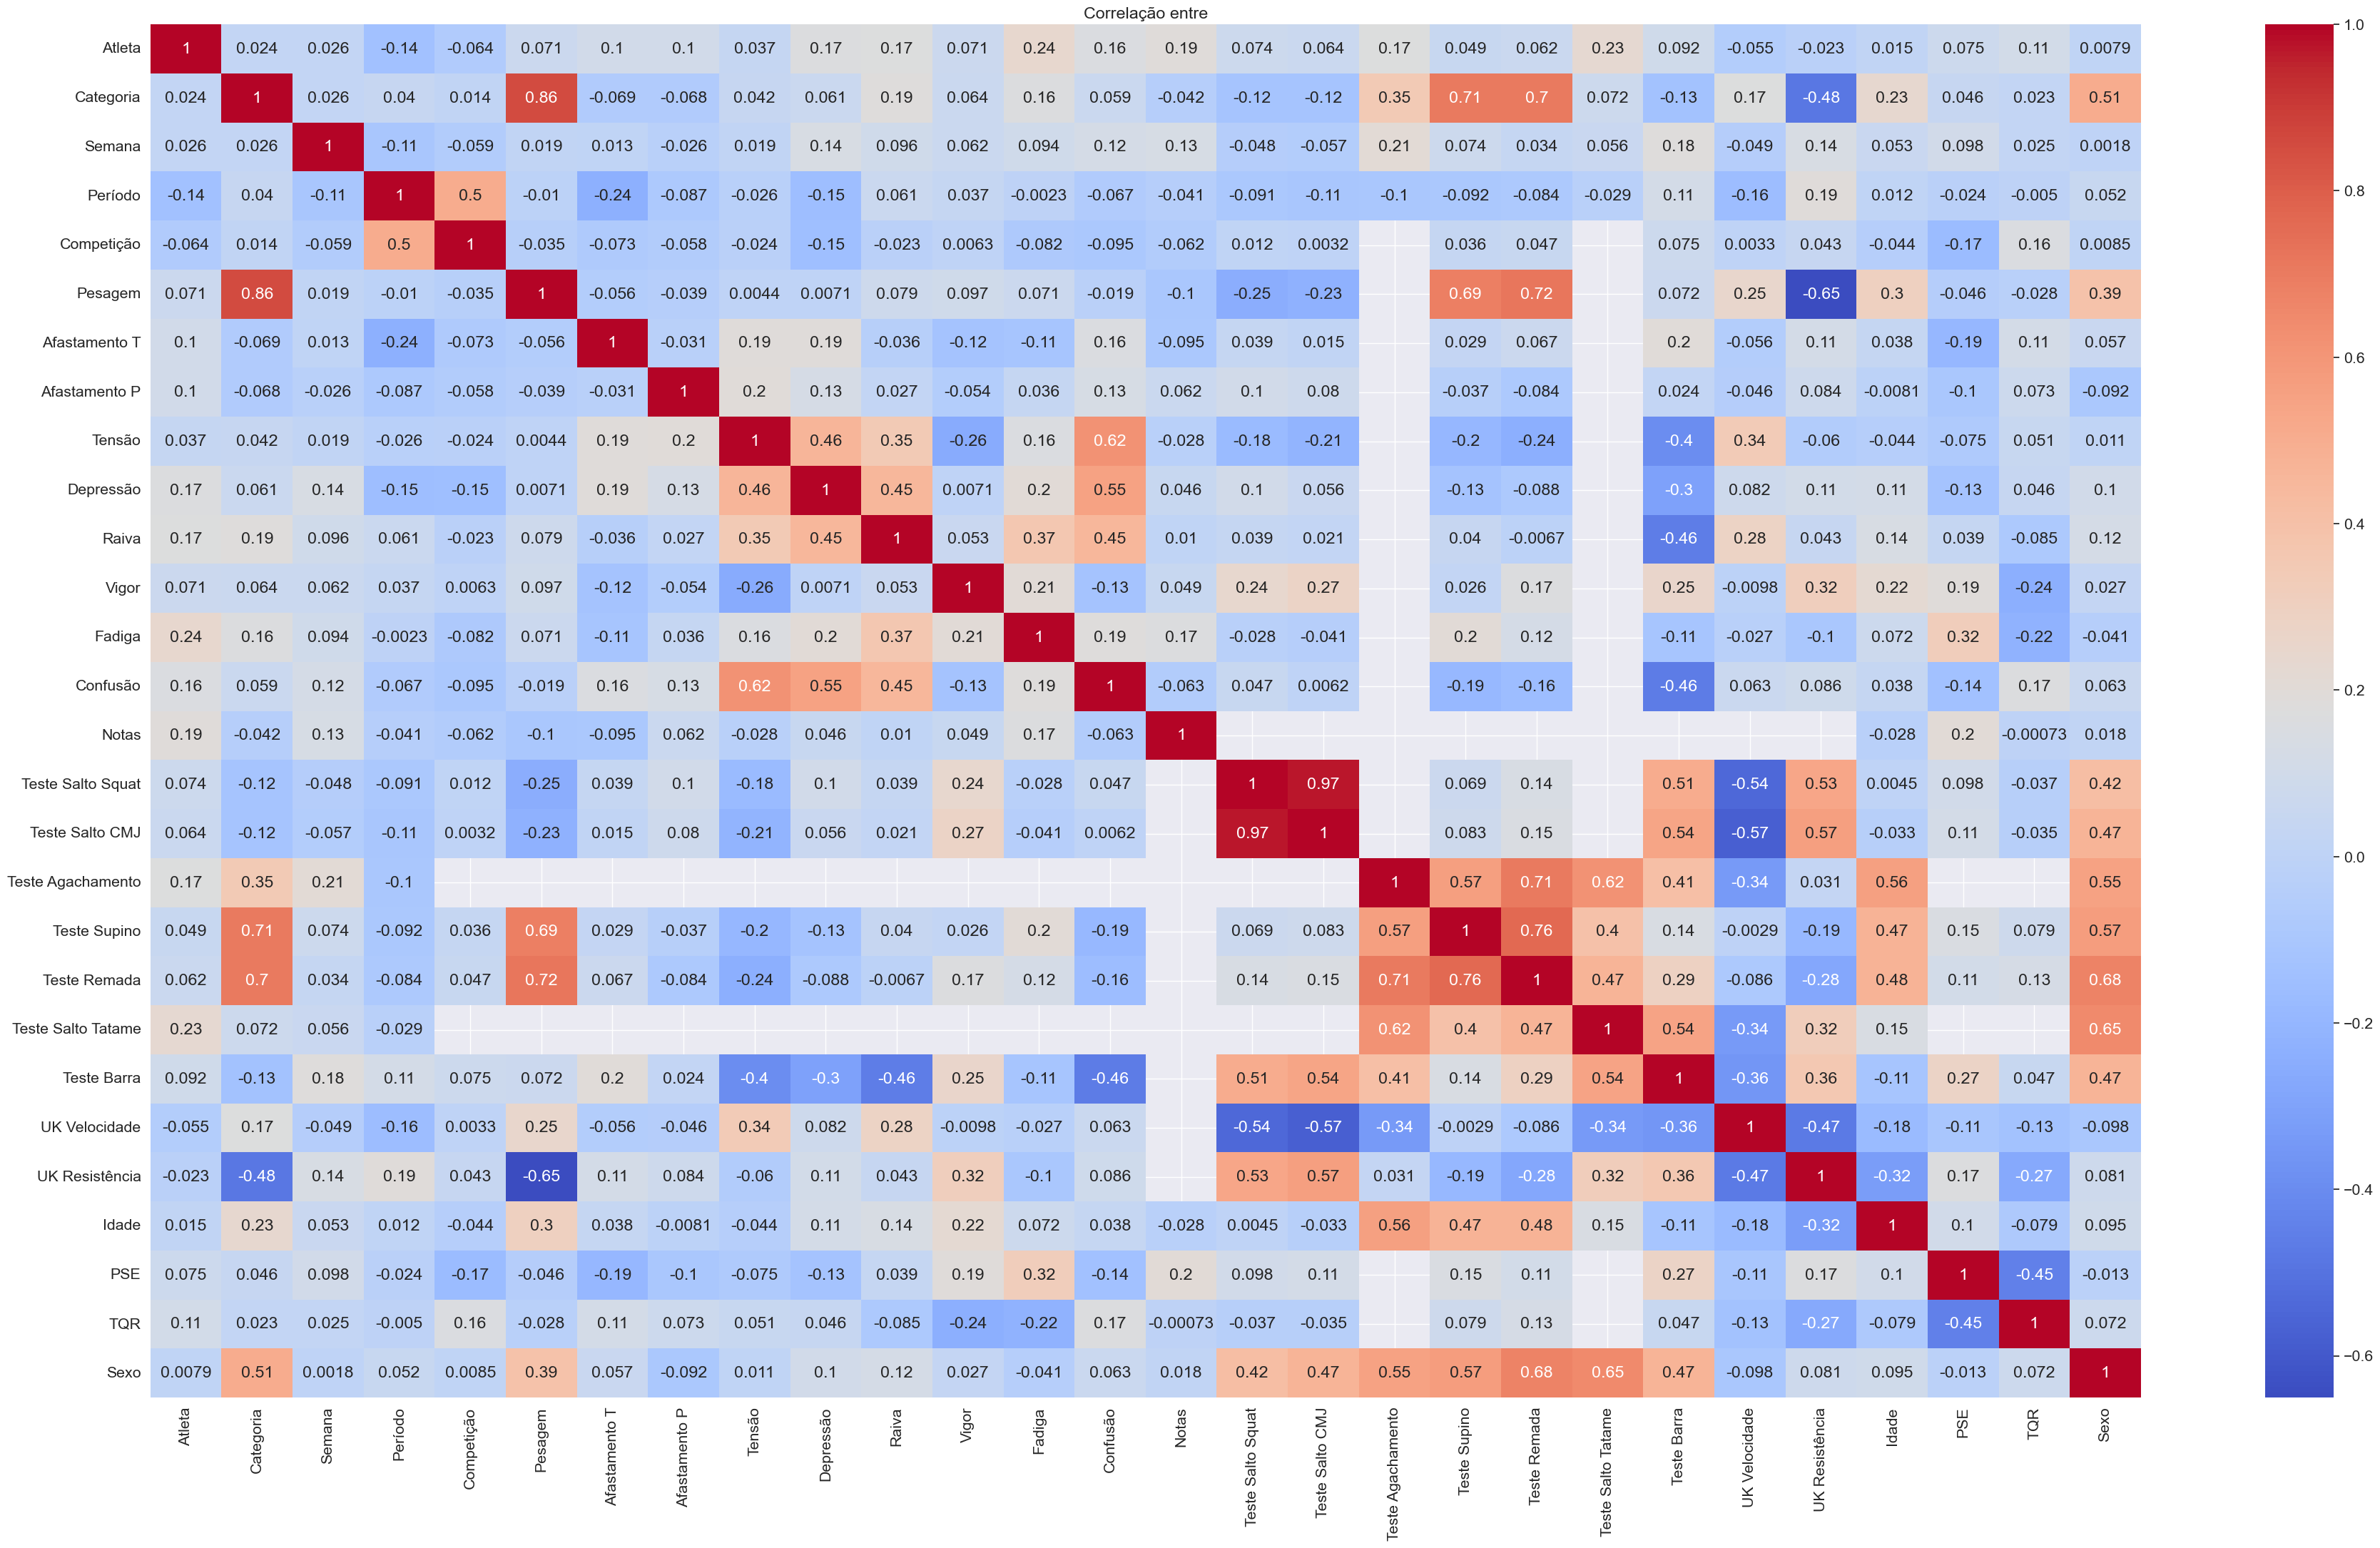

In [28]:
# Correlação apenas entre os scores AQ
aq_scores = df.loc[:, ]

corr = aq_scores.corr()

plt.figure(figsize=(45,25))
sns.set(font_scale=1.4)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre')
plt.show()


PSE → mede esforço percebido durante/apos exercício.

TQR → mede estado de recuperação antes de novo estímulo.


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
# Instale se não tiver: pip install mord
!pip install mord
from mord import LogisticIT 

# 1. Selecionando as variáveis preditoras (X) e o alvo (y)
# Vamos usar as variáveis que você processou anteriormente
features = ['Idade', 'Sexo', 'PSE', 'TQR', 'Competição', 'Período', 
            'Tensão', 'Depressão', 'Raiva', 'Vigor', 'Fadiga', 'Confusão']

# Removendo linhas com valores faltantes nas features para o modelo não quebrar
df_model = df.dropna(subset=features + ['Afastamento'])

X = df_model[features]
y = df_model['Afastamento'].astype(int)

# 2. Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Modelo de Regressão Ordinal (Immediate Threshold)
# O LogisticIT é ideal para quando os estados têm uma ordem natural (0 < 1 < 2 < 3)
model_ordinal = LogisticIT()
model_ordinal.fit(X_train, y_train)

# 4. Predições e Avaliação
y_pred = model_ordinal.predict(X_test)

print("--- Relatório de Classificação Ordinal ---")
print(classification_report(y_test, y_pred))

print("--- Matriz de Confusão ---")
print(confusion_matrix(y_test, y_pred))


Defaulting to user installation because normal site-packages is not writeable


ModuleNotFoundError: No module named 'mord'

In [ ]:
import statsmodels.miscmodels.ordinal_model as ordinal

# O statsmodels exige que o modelo seja definido de forma um pouco diferente
mod_prob = ordinal.OrderedModel(y_train, X_train, distr='logit')
res_prob = mod_prob.fit(method='bfgs')

print(res_prob.summary())